<a href="https://colab.research.google.com/github/Lakshya-13-04/Credit-Card-Fraud-Detection-Risk-Analyst/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement:**
1. A credit card is a small thin plastic or fiber card that incorporates
information about the person such as a picture or signature and the
person’s name on it to charge purchases and services to his linked
account. Charges are debited regularly. Nowadays, card data is read by
ATMs, swiping machines, store readers, banks and online transactions.
2. Each card has a unique card number which is very important. Its security
mainly relies on the physical security of the card and also the privacy of the
credit card number. There is a rapid growth in credit card transactions
which has led to substantial growth in scam cases.
3. Credit card fraud is expanding heavily because fraud financial loss is
increasing drastically. Multiple data mining and statistical techniques are
used to catch fraud. Therefore the detection of fraud using efficient and
secured methods are very important.

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/creditcard.csv')

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
# Checking for null values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


#### From the documentation we can see that It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot see the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.

#### calculate the number of genuine transactions, number of fraud transactions and the percentage of fraud transactions.

In [ ]:
not_fraud = df[df['Class'] == 0]
genuine_transaction = len(not_fraud)
print(f'The Number of Genuine Transaction = {genuine_transaction}')

The Number of Genuine Transaction = 284315


In [ ]:
fraud = df[df['Class'] == 1]
not_genuine_transaction = len(fraud)
print(f'The Number of Fraud Transactions = {not_genuine_transaction}')

The Number of Fraud Transactions = 492


In [ ]:
percentage = (not_genuine_transaction * 100)/(not_genuine_transaction + genuine_transaction)
print(f'The Percentage of Fraud transactions is: {percentage}%')

The Percentage of Fraud transactions is: 0.1727485630620034%


#### Visualize the genuine and fraudlent transaction using bar graph

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df['Class'].unique()

array([0, 1])

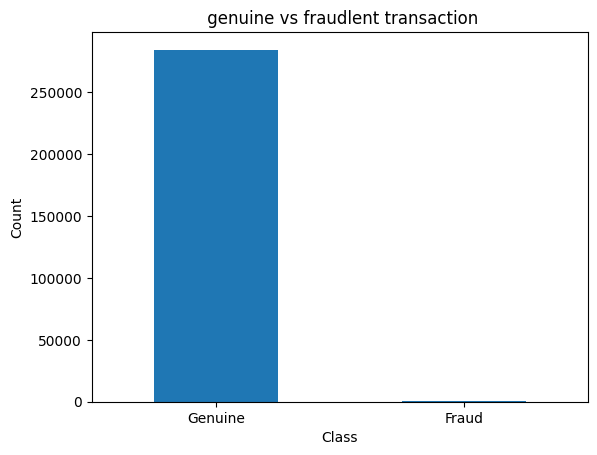

In [ ]:
label = ['Genuine', 'Fraud']
count_classes = df.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot =0)
plt.xticks(range(2),label)
plt.title(' genuine vs fraudlent transaction')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

#### Using the Standard Scaler module, normalize the amount column and store the new values in the NormalizedAmount column.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
sc = StandardScaler()
df['Normalized Amount'] = sc.fit_transform(df['Amount'].values.reshape(-1,1))

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Normalized Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403


In [ ]:
df.drop(['Amount', 'Time'], inplace = True , axis = 1)

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Normalized Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


### Logistic Regression Model

In [ ]:
X = df.drop(columns = 'Class')
y = df['Class']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [ ]:
# Spliting the Data
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify= y, test_size = 0.30, random_state= 23)

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = log_model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f'The accuracy of Model is: {acc*100}% \n')

cm = confusion_matrix(y_test, y_pred)
print(f'The Confusion Matrix of Model is: {cm} \n')

pre = precision_score(y_test, y_pred)
print(f'The Precision of model is: {pre} \n')

recall = recall_score(y_test, y_pred)
print(f'The Recall score of model is: {recall} \n')

f1Score = f1_score(y_test, y_pred)
print(f'The f1 score of model is: {f1Score}')

The accuracy of Model is: 99.92392589211521% 

The Confusion Matrix of Model is: [[85284    11]
 [   54    94]] 

The Precision of model is: 0.8952380952380953 

The Recall score of model is: 0.6351351351351351 

The f1 score of model is: 0.7430830039525692


### Descision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = DT_model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f'The accuracy of Model is: {acc*100}% \n')

cm = confusion_matrix(y_test, y_pred)
print(f'The Confusion Matrix of Model is: {cm} \n')

pre = precision_score(y_test, y_pred)
print(f'The Precision of model is: {pre} \n')

recall = recall_score(y_test, y_pred)
print(f'The Recall score of model is: {recall} \n')

f1Score = f1_score(y_test, y_pred)
print(f'The f1 score of model is: {f1Score}')

The accuracy of Model is: 99.90402958697612% 

The Confusion Matrix of Model is: [[85254    41]
 [   41   107]] 

The Precision of model is: 0.722972972972973 

The Recall score of model is: 0.722972972972973 

The f1 score of model is: 0.722972972972973


In [ ]:
# to plot the decision tree
from sklearn.tree import plot_tree

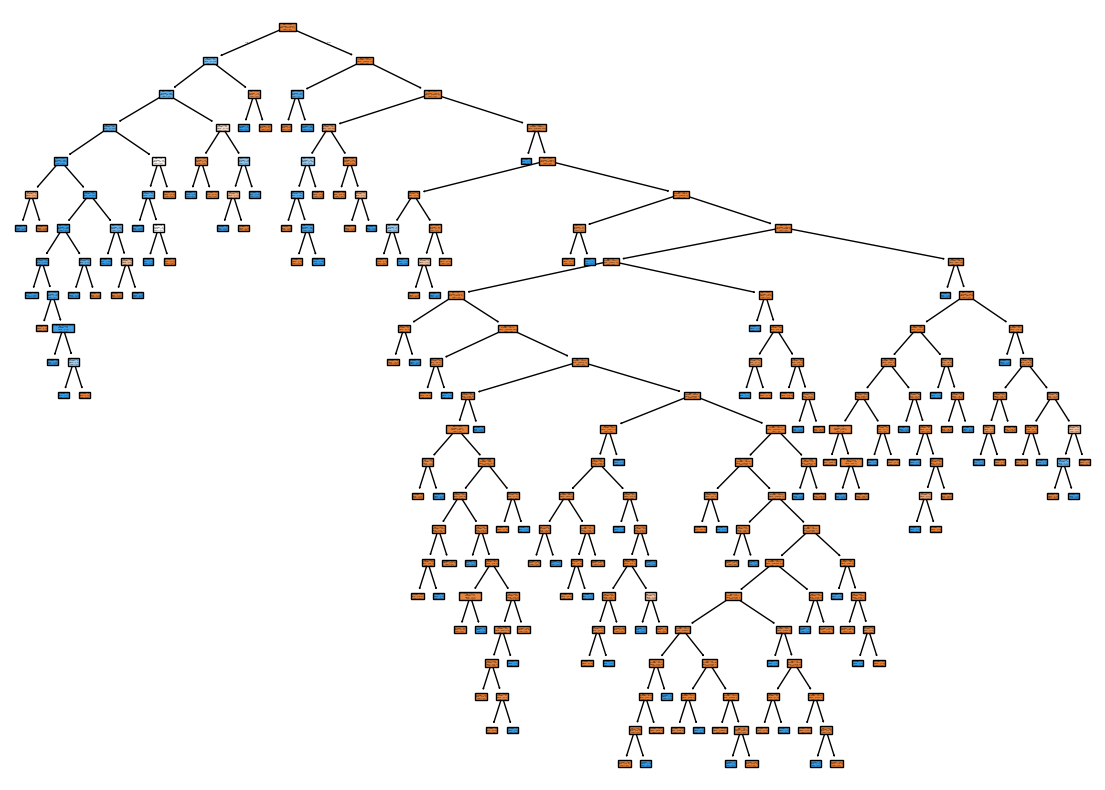

In [ ]:
plt.figure(figsize = (14,10))
plot_tree(DT_model, feature_names= X_train.columns , filled=  True, class_names= True )
plt.show()

### Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = RF_model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f'The accuracy of Model is: {acc*100}% \n')

cm = confusion_matrix(y_test, y_pred)
print(f'The Confusion Matrix of Model is: {cm} \n')

pre = precision_score(y_test, y_pred)
print(f'The Precision of model is: {pre} \n')

recall = recall_score(y_test, y_pred)
print(f'The Recall score of model is: {recall} \n')

f1Score = f1_score(y_test, y_pred)
print(f'The f1 score of model is: {f1Score}')

The accuracy of Model is: 99.94733330992591% 

The Confusion Matrix of Model is: [[85282    13]
 [   32   116]] 

The Precision of model is: 0.8992248062015504 

The Recall score of model is: 0.7837837837837838 

The f1 score of model is: 0.8375451263537906


### Out of Random forest, logistic regression, descision tree model we have highest accuracy for **Random Forest Model** that is equal to **99.947% accuracy**